# Mapping the Gaps — first hour

**Not a solution.** The technique is **normalising before comparing**, and the reason
it deserves an hour is that the un-normalised version produces a confident, clean,
completely wrong answer.

The brief is unusually direct: *"Deprivation is a measure of access, not a label on
people; recorded crime shows what is **reported**, not what happened."* Both halves of
that sentence are traps laid in the data.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from lib.loader import load
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

ch = load('c02-mapping-the-gaps')
for c in ch.caveats():
    print('CAVEAT:', c[:150])
ch

CAVEAT: lsoa_deprivation: LSOA-level deprivation rank and domain scores. SYNTHETIC stand-in for IoD 2025 on the real English LSOA grain. A measure of ACCESS i
CAVEAT: lsoa_crime_monthly: Counts of crime RECORDED by police, by LSOA, month and category. SYNTHETIC. This measures reporting and recording, not incidence —


<Challenge c02-mapping-the-gaps (lsoa_deprivation=33,755, lsoa_crime_monthly=2,430,360)>

In [2]:
ch.describe('lsoa_crime_monthly')

,name,type,description
0,lsoa_code,string,LSOA code. Joins to lsoa_deprivation — you nee...
1,month,date,"First day of the month, ISO-8601."
2,crime_category,string,Recorded crime category. The deprivation gradi...
3,recorded_count,integer,Offences RECORDED that month. Not offences com...


## Trap 1 — raw counts are a population map

The most common mistake in civic-data work, and it is one line to check.

In [3]:
dep = ch.tables['lsoa_deprivation']
crime = ch.tables['lsoa_crime_monthly']

totals = (crime.groupby('lsoa_code', as_index=False).recorded_count.sum()
               .merge(dep[['lsoa_code','resident_population','imd_decile','local_authority']],
                      on='lsoa_code'))
totals['rate_per_1000'] = totals.recorded_count / totals.resident_population * 1000

print(f'population range: {totals.resident_population.min():,} to {totals.resident_population.max():,}  ({totals.resident_population.max()/totals.resident_population.min():.1f}x)')
print()
print(f'corr(raw count, population) = {totals.recorded_count.corr(totals.resident_population):+.3f}')
print(f'corr(rate,      population) = {totals.rate_per_1000.corr(totals.resident_population):+.3f}')

population range: 1,000 to 3,999  (4.0x)

corr(raw count, population) = +0.776
corr(rate,      population) = +0.001


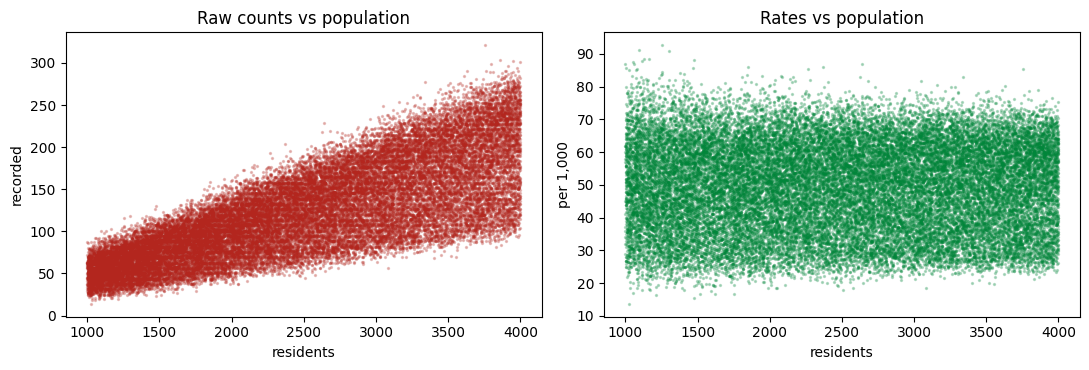

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
ax[0].scatter(totals.resident_population, totals.recorded_count, s=2, alpha=0.25, color='#b3261e')
ax[0].set_title('Raw counts vs population'); ax[0].set_xlabel('residents'); ax[0].set_ylabel('recorded')
ax[1].scatter(totals.resident_population, totals.rate_per_1000, s=2, alpha=0.25, color='#00863a')
ax[1].set_title('Rates vs population'); ax[1].set_xlabel('residents'); ax[1].set_ylabel('per 1,000')
plt.tight_layout(); plt.show()

### The two 'worst areas' lists disagree

This is what the mistake costs in practice — a different set of places, and therefore
a different set of decisions.

In [5]:
by_count = set(totals.nlargest(50, 'recorded_count').lsoa_code)
by_rate  = set(totals.nlargest(50, 'rate_per_1000').lsoa_code)
print(f'top 50 by raw count and by rate share {len(by_count & by_rate)} of 50 areas')

top 50 by raw count and by rate share 2 of 50 areas


## Trap 2 — recorded crime is not crime

Now the harder one. Compute the deprivation gradient **per category** rather than
overall, and the categories disagree with each other.

Remember `imd_decile` 1 = **most** deprived, so a *negative* correlation means more
recorded crime in deprived areas.

In [6]:
rows = []
for cat, sub in crime.groupby('crime_category'):
    t = (sub.groupby('lsoa_code', as_index=False).recorded_count.sum()
            .merge(dep[['lsoa_code','resident_population','imd_decile']], on='lsoa_code'))
    t['rate'] = t.recorded_count / t.resident_population * 1000
    rows.append({'category': cat,
                 'rate_per_1000': t.rate.mean(),
                 'corr_with_decile': t.rate.corr(t.imd_decile)})

grad = pd.DataFrame(rows).sort_values('corr_with_decile')
grad['direction'] = grad.corr_with_decile.apply(
    lambda r: 'more in DEPRIVED' if r < -0.05 else ('more in AFFLUENT' if r > 0.05 else 'flat'))
grad

,category,rate_per_1000,corr_with_decile,direction
0,Anti-social behaviour,14.746983,-0.928633,more in DEPRIVED
3,Shoplifting,3.930647,-0.844047,more in DEPRIVED
1,Burglary,4.495899,-0.680456,more in DEPRIVED
4,Vehicle crime,5.258941,-0.616294,more in DEPRIVED
2,Criminal damage and arson,6.836262,-0.571300,more in DEPRIVED
5,Violence and sexual offences,13.964583,0.217010,more in AFFLUENT


### Stop and look at that table

Five categories are concentrated in deprived areas. **Violence runs the other way.**

The correlation is real, the data is real, and the chart would be clean. And the
conclusion — *violence is an affluent-area problem* — is wrong, because what changes
across deciles is not only how much happens but **how much gets reported**.

Burglary is the useful comparator: it is well reported everywhere because people claim
on insurance, so its recorded figures track reality more closely. When two categories
disagree this sharply, the difference is telling you about **reporting**, not about crime.

The true incidence is not in this dataset. It is not in the real one either. That is
the actual working condition, and naming it is what separates a strong entry.

## Trap 3 — the index already contains crime

The deprivation index is built from seven domains, and one of them is crime. So
correlating recorded crime against the overall rank is partly correlating crime with
itself.

In [7]:
full = totals.merge(dep.drop(columns=['resident_population','imd_decile','local_authority']), on='lsoa_code')
others = ['income_score','employment_score','education_score','health_score',
          'barriers_score','living_environment_score']
full['imd_excl_crime'] = full[others].mean(axis=1)

print(f'corr(rate, imd_rank)             = {full.rate_per_1000.corr(full.imd_rank):+.3f}')
print(f'corr(rate, crime_score)          = {full.rate_per_1000.corr(full.crime_score):+.3f}   <- circular')
print(f'corr(rate, IMD excluding crime)  = {full.rate_per_1000.corr(full.imd_excl_crime):+.3f}   <- honest')

corr(rate, imd_rank)             = -0.921
corr(rate, crime_score)          = +0.689   <- circular
corr(rate, IMD excluding crime)  = +0.869   <- honest


## The ecological fallacy, stated plainly

Everything above is **area-level**. None of it is a statement about any person.

If an area with more deprivation records more anti-social behaviour, that does not mean
deprived *people* commit more of it — the offender may not live there, may not be
deprived, and the residents are overwhelmingly not involved at all. Inferring individual
behaviour from area statistics is the **ecological fallacy**, and it is the failure mode
that turns a civic-data project into something that harms the people it was meant to help.

The brief's instruction that names must not imply otherwise is a design constraint on
your outputs too: `recorded_count`, not `crime_count`; *areas where more is reported*,
not *high-crime communities*.

In [8]:
# Small areas rank unstably. Poisson noise dominates when counts are low, so the
# 'worst' small area is often just the luckiest draw — worth knowing before anyone
# targets a resource at it.
small = totals[totals.resident_population < totals.resident_population.quantile(0.1)]
large = totals[totals.resident_population > totals.resident_population.quantile(0.9)]
print(f'rate variance, smallest decile of LSOAs : {small.rate_per_1000.var():.2f}')
print(f'rate variance, largest decile           : {large.rate_per_1000.var():.2f}')

rate variance, smallest decile of LSOAs : 198.91
rate variance, largest decile           : 166.69


## Where to go next

- Compare categories against each other before drawing any conclusion from one.
- If you build an index, decide whether crime belongs in it and say why.
- `lsoa_digital_exclusion` is not in this build: its source (`deri`) has not cleared
  licence review, so it ships as a pointer.
- Any map you produce should state what it measures in its title. *"Recorded
  anti-social behaviour per 1,000 residents"* is honest. *"Problem areas"* is not.